   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd   Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW  1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW  4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW  6.71   0   0
          No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd     Iws  \
43822  43823  2014     12   31    22    8.0   -22  -4.0  1034.0   NW  246.72   
43823  43824  2014     12   31    23   12.0   -21  -3.0  1034.0   NW  249.85   

       Is  Ir  
43822   0   0  
43823   0   0  


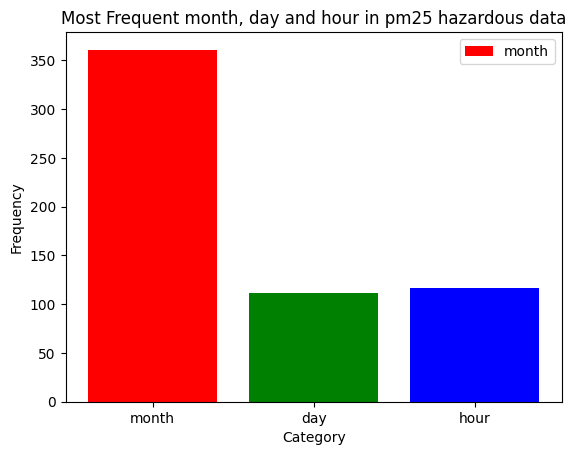

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('6.PRSA_data_2010.1.1-2014.12.31.csv')
print(df.head(3))
print(df.tail(2))
df = df.drop(['DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir'], axis=1)
df = df.dropna()
df.to_csv('pm25_data_2010.1.1-2014.12.31.csv', index=False)
new_df = pd.read_csv('pm25_data_2010.1.1-2014.12.31.csv')
filtered_df = new_df[new_df['pm2.5'] > 300]
filtered_df.to_csv('pm25_hazardous_data_2010.1.1-2014.12.31.txt', sep=',', index=False)
txt_df = pd.read_csv('pm25_hazardous_data_2010.1.1-2014.12.31.txt', sep=',')
txt_df.to_excel('pm25_hazardous_data_2010.1.1-2014.12.31.xlsx', index=False)
txt_df = pd.read_csv('pm25_hazardous_data_2010.1.1-2014.12.31.txt', sep=',')
month_mode = txt_df['month'].mode()[0]
month_count = txt_df['month'].value_counts()[month_mode]
day_mode = txt_df['day'].mode()[0]
day_count = txt_df['day'].value_counts()[day_mode]
hour_mode = txt_df['hour'].mode()[0]
hour_count = txt_df['hour'].value_counts()[hour_mode]
labels = ['month', 'day', 'hour']
counts = [month_count, day_count, hour_count]
colors = ['red', 'green', 'blue']
plt.bar(labels, counts, color=colors)
plt.title('Most Frequent month, day and hour in pm25 hazardous data')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.xticks(range(len(labels)), labels)
plt.legend(labels)
plt.savefig('pm25_hazardous_month_day_hour.png', dpi=400)